## Pattern Recognition and Machine Learning - Assignment I
### Year 2025-2026- Semester II
### CCE2502
####  developed by - Adrian Muscat, 2026
---
### Write your name, ID Card Number below
Dave Galea, 0283404L 

---


In this assignment you will be developing Python code to experiment with the k-Nearest Neighbour (k-NN) predictive model.


All questions are graded and total to 100.
This assignment contributes to a maximum of 30% of the final study unit score. 

In case of any ideas or expected results obtained from literature, cite the proper publication. In general you should not cite blogs (If you do use blogs or AI tools, trace the original document and cite that)

Submit on VLE:
1. This jupyter notebook complete with answers to the questions (.ipynb)
2. A pdf copy of the same jupyter notebook with all cells executed
3. The completed and signed plagiarism and collusion form

All zipped into one file.

NOTE: before you save your final file, **reset the kernel and execute all the cells**.

## NOTE: 

This work is to be attempted individually. It is essential that the work you eventually submit and present for your assignment consists only of your own work; use of copied material will be treated as plagiarism or collusion. Discussion is only permitted on general issues, and it is absolutely forbidden to discuss specific details with anyone and/or share results.

Below are links to the Plagiarism and Collusion form:

https://www.um.edu.mt/media/um/docs/faculties/ict/mainfacultyofictfiles/PlagiarismForm.pdf

or at:
https://www.um.edu.mt/ict/students/formsguidelines/


In [1]:
# Execute this to record library versions installed on your system
import matplotlib
import numpy
import sklearn
import sys

print("Python version : ", sys.version)
print("numpy version : ", numpy.__version__)
print("sklearn version : ", sklearn.__version__)
print("matplotlib version : ", matplotlib.__version__)

Python version :  3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]
numpy version :  2.4.3
sklearn version :  1.8.0
matplotlib version :  3.10.8


## This assignment consists of two tasks, each split into a  number of questions. Answer all questions.

# Task I: Selecting the neighbours and calculating probabilities
### For this task you are only allowed to use the following python modules (use of other modules will result in loss of marks)
1. **numpy**
2. **matplotlib.pyplot**

Considering a circle (hyper sphere in higher dimensions) predicting probabilities in classification and regression
1. Given ready made classification and regression algorithm, and an accuracy function
2. Load the two datasets
3. Train the two models, vary k from 1 to 21 and plot the accuracy vs k. which k maximizes accuracy?
4. Copy the function, rename it to RadiusNN and modify it such that the neighbours considered for regression or classification are those that are within the circle defined by the test point as the centre of the circle and radius, r,  which should be considered as a hyper-parameter of the model. We call call this model r-NN instead of k-NN.
5. train the two models and vary r and plot the accuracy vs r. which r maximises accuracy?
6. discuss (no more the 50 words) the choice between k and r, are the results as expected  

## Preamble : Binary k-NN classifier function
You will use the **predict_kNN_euclidian()** function to answer some of the questions
### DO NOT MODIFY the below CELL

In [2]:

# DO NOT MODIFY THIS CELL
import numpy as np

def predict_kNN_euclidian(k, X_train, y_train, X_query):
    """
    Inputs:
    ----------
    k : k nearest neighbours considered
    X_train : (MxN) feature array in n-dimensions,
                (M = number of examples, N = number of features)
    y_train : (M,) output labels in any dimension, typically 1-dimension
    X_query : (mxN) dimensional real array, m independent queries 
                    for one query shape is (1,2)
                    
    Outputs:
    --------
    Predictions for each instance in X_query, m-dimensional
    """
    def k_nearest_neighbour_euclidian(k, X_train, y_train, x_new):
        M = y_train.shape[0]
        dist = ((X_train-x_new)**2).sum(axis=1)
        DD = np.concatenate((X_train, y_train.reshape((M,1)), 
                             dist.reshape((M,1))), axis=1)
        DDs = DD[np.argsort(DD[:,3])]
        r = DDs[0:k,2].sum()
        c = 1 if r > k/2. else 0
        #return DDs[0:k,:], r, c 
        return c 
    
    m = X_query.shape[0]
    y = np.zeros(m)
    for i in range(m):
        y[i] = k_nearest_neighbour_euclidian(k, X_train, y_train, 
                                             X_query[i])
    return y

## First we load the dataset

In [3]:
# DO NOT MODIFY THIS CELL

import pickle
import numpy as np

with open("Task1_dataset_classification.pkl", "rb") as file:
    data = pickle.load(file)

X, y = data['X'], data['y']

assert (np.round(X.sum(),3), y.sum()) == (12.557, 501), "Checksum test failed"

## Question I_a: Generate a scatter plot of the 2-dimensional classification dataset [5 marks]

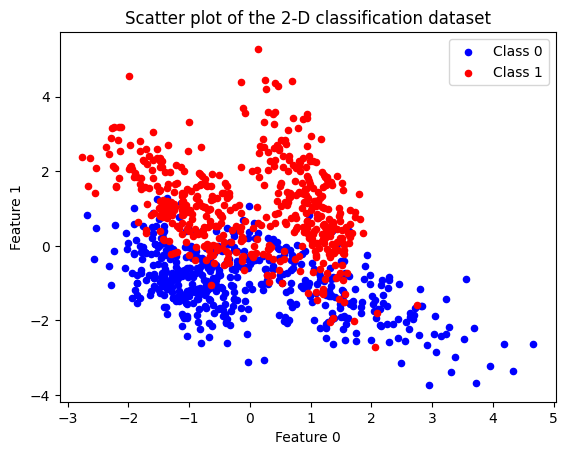

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X[y==0,0], X[y==0,1],
            color="blue",
            label="Class 0",
            s = 20)

plt.scatter(X[y==1,0], X[y==1,1],
            color="red",
            label="Class 1",
            s = 20)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend()
plt.title("Scatter plot of the 2-D classification dataset")
plt.show()

## Question I_b : Complete the below function that partitions a dataset into two parts, the training and the testing sets. [5 marks]

In [5]:
def partition_dataset(X, y, s= 0.8, shuffle = True, rng_seed = 0):
    """
    Inputs:
    -------
    X : input features array of size MxN
    y : output label vector of size M
    s : fraction of dataset copied to training dataset
    shuffle : randomly shuffle dataset before splitting (True/false)
    seed : seed for random number generation

    Outputs:
    --------
    X_train : input features in training set, size (Ms)xN
    X_test  : input features in testing set, size (M(1-s)xN
    y_train : Output labels in training set, size Ms
    y_test  : Output labels in testing set, size M(1-s)
    """
    
    M = X.shape[0]
    train_count = int(M * s)
    
    indices = np.arange(M) # keep order
    
    if shuffle:
        rng = np.random.default_rng(rng_seed)
        rng.shuffle(indices)
    
    X = X[indices]
    y = y[indices]
    
    X_train = X[:train_count]
    y_train = y[:train_count]
    
    X_test = X[train_count:]
    y_test = y[train_count:]
    
    return X_train, y_train, X_test, y_test
    

## Question I_c: Complete the below function to test the **partition_dataset()** function developed above and use the test function to test the partition_dataset() function [10 marks]

In [6]:
def test_partition_dataset_function():
    
    # write down some test examples split into train and test sets
    # (you can copy some examples from the dataset)
    # add your code here 

    # examples below are expected for an 80% split 
    X_full = np.array([[0,0],
                       [1,1],
                       [2,2],
                       [3,3],
                       [4,4]])
    
    y_full = np.array([1,0,1,0,1])

    X_train_expected = np.array([[0,0],
                                 [1,1],
                                 [2,2],
                                 [3,3]])
    
    X_test_expected = np.array([[4,4]])

    y_train_expected = np.array([1,0,1,0])

    y_test_expected = np.array([1])

    # call partition_function
    # add your code here
    X_train_test, y_train_test, X_test, y_test = partition_dataset(X_full, y_full, s = 0.8, shuffle = False)
    
    # compare splits to what is expected 
    # use assert keyword to output success or failure
    # add your code here

    '''
    Although visual verification of matching is less accurate than the assert method, 
    I added it to visually confirm that the split is working correctly
    '''
    
    print("Expected X_train:\n", X_train_expected)
    print("Actual X_train:\n", X_train_test)

    print("\nExpected X_test:\n", X_test_expected)
    print("X_test:\n", X_test)

    print("\nExpected y_train:\n", y_train_expected)
    print("y_train:\n", y_train_test)

    print("\nExpected y_test:\n", y_test_expected)
    print("y_test:\n", y_test)
    
    assert np.array_equal(X_train_test, X_train_expected), "X_train mismatch"
    assert np.array_equal(X_test, X_test_expected), "X_test mismatch"
    assert np.array_equal(y_train_test, y_train_expected), "y_train mismatch"
    assert np.array_equal(y_test, y_test_expected), "y_test mismatch"

# use the test function to test the partition function   
# add your code here
test_partition_dataset_function()


Expected X_train:
 [[0 0]
 [1 1]
 [2 2]
 [3 3]]
Actual X_train:
 [[0 0]
 [1 1]
 [2 2]
 [3 3]]

Expected X_test:
 [[4 4]]
X_test:
 [[4 4]]

Expected y_train:
 [1 0 1 0]
y_train:
 [1 0 1 0]

Expected y_test:
 [1]
y_test:
 [1]


## Question I_d : choose k, from [1, 3, 5, ..., 19, 81], that maximises the accuracy metric. [5 marks]
Explain the methodolgy in no more than 50 words

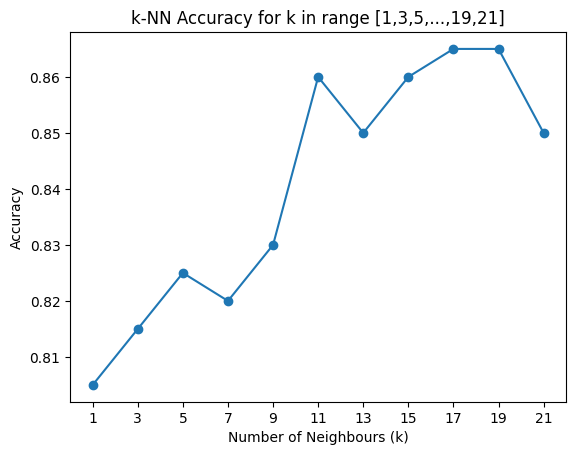

Highest Accuracy: 0.865
Optimal k values: [17, 19]


In [7]:
# add your code here
# In accordance to the much appreciated reply on the VLE forums, K will be taken up to 21. 
# Split of dataset (80% training)
X_train, y_train, X_test, y_test = partition_dataset(X, y, s = 0.8, shuffle = True, rng_seed =0)

# calculating accuracy 
def calc_accuracy(y_actual, y_predict):
    correct_predictions = np.sum( y_actual == y_predict)
    total_predictions = len(y_actual)
    
    return correct_predictions / total_predictions 

#Define list of k 
k_vals = [k for k in range(1, 22, 2)]
acc_vals_k = []

for current_k in k_vals:
    predictions = predict_kNN_euclidian(current_k, X_train, y_train, X_test) # predict labels of X test set 
    acc = calc_accuracy(y_test, predictions) # compare predictions with the actuals from test set 
    acc_vals_k.append(acc)

plt.figure()
plt.plot(k_vals, acc_vals_k, marker='o')
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Accuracy")
plt.title("k-NN Accuracy for k in range [1,3,5,...,19,21]")
plt.xticks(k_vals) # showing only values tested
plt.show() 

# Find the highest accuracy
top_acc_k = max(acc_vals_k)

# Find all k values that achieve this accuracy
top_ks = [k_vals[i] for i, acc in enumerate(acc_vals_k) if acc == top_acc_k]

print("Highest Accuracy:", top_acc_k)
print("Optimal k values:", top_ks)





### Question I_d: Methodology

Accuracy as a metric was defined as the fraction of correct predictions on the test set. For each odd k from 1 to 21, the k-NN model predicted labels for the test set (using the provided function), and accuracy was computed. The K-values giving the highest accuracy were selected.

## Question I_e: Complete the below function, **predict_kNN_radius()**, such that the neighbours considered for predicting the output are those that are within a circle defined by the query vector as the centre of the circle of radius r. We will call this model r-NN instead of k-NN. [10 marks]


In [8]:
def predict_kNN_radius(r, X_train, y_train, X_query):
    """
    Inputs:
    ----------
    r : r is the radius of the circle with centre X_query[i] that encloses the nearest neighbours
    X_train : (MxN) feature array in n-dimensions,
                (M = number of examples, N = number of features)
    y_train : (M,) output labels in any dimension, typically 1-dimension
    X_query : (mxN) dimensional real array, m independent queries 
                    for one query shape is (1,2)
                    
    Outputs:
    --------
    Predictions for each instance in X_query, m-dimensional
    """
    
    # below copy the code from predict_kNN_euclidian() and modify it for a r-NN classifier
    def r_nearest_neighbour_radius(r, X_train, y_train, x_new):
        M = y_train.shape[0] # no. of training examples 
        dist = ((X_train - x_new) ** 2).sum(axis=1)
        DD = np.concatenate((X_train, y_train.reshape((M, 1)),
                             dist.reshape((M, 1))), axis=1)
        # filter neighbours within radius r
        neighbours = DD[DD[:, -1] <= r**2]
        
        if neighbours.shape[0] == 0:
            # no neighbours found within radius -> use majority class
            c = int(np.round(y_train.mean()))
        else:
            # if sum > half neighbour count, predict 1, else 0
            c = 1 if neighbours[:, -2].sum() > neighbours.shape[0]/2 else 0
        return c

    m = X_query.shape[0]
    y = np.zeros(m)
    for i in range(m):
        y[i] = r_nearest_neighbour_radius(r, X_train, y_train,
                                          X_query[i])
    
    return y

## Question I_f : Choose r that maximises the accuracy metric. [5 marks]

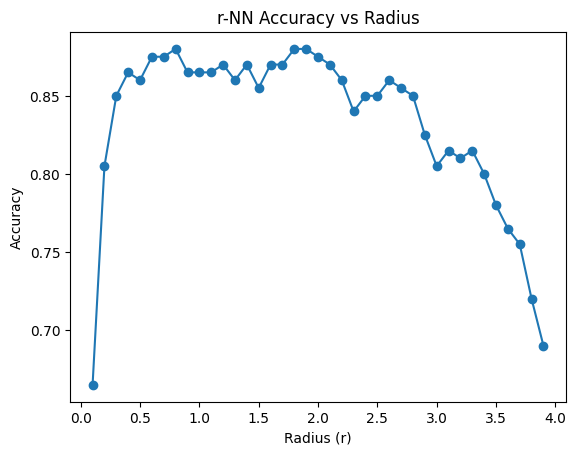

Highest Accuracy: 0.88
Optimal r values: [0.8, 1.8, 1.9]


In [9]:
# add your code here
X_train, y_train, X_test, y_test = partition_dataset(X, y, s = 0.8, shuffle = True, rng_seed =0)

#Define list of r
r_vals = np.arange(0.1, 4, 0.1) # 4 chosen due to clear downward trend after ~3.0
acc_vals_r = []

for current_r in r_vals:
    predictions = predict_kNN_radius(current_r, X_train, y_train, X_test) # predict labels of X test set 
    acc = calc_accuracy(y_test, predictions) # compare predictions with the actuals from test set 
    acc_vals_r.append(acc)

plt.figure()
plt.plot(r_vals, acc_vals_r, marker='o')
plt.xlabel("Radius (r)")
plt.ylabel("Accuracy")
plt.title("r-NN Accuracy vs Radius")
plt.show() 

# Find the highest accuracy
top_acc_r = max(acc_vals_r)

# Find all r values that achieve this accuracy
top_rs = [r_vals[i] for i, acc in enumerate(acc_vals_r) if acc == top_acc_r]

print("Highest Accuracy:", top_acc_r)
print("Optimal r values:", [round(float(r), 3) for r in top_rs])



## Question I_g: Add python code to both classifier functions (k-NN and r-NN)  such that the same functions return the probability of the class predicted. [5 marks]

i.e In the current implementation, the k-NN and r_NN functions return a vector whose elements are the predicted class for each query instance.

e.g. **y = [ 1, 0, 1, 1, 0, 0, 0]**

The modified function will, in addition, return the probability of the classes in y,

e.g **p = [0.876, 0.567, 0.902, 0.981, 0.654, 0.812, .765]**

In [10]:
# Copy the functions here and add your code
# Predict the output for a few query instances as a demonstration of the new functions
# explain using comments within the python code how the probability is computed

# k-NN
"""
Probability calculation:
c = predicted class 
r = number of neighbours voting for predicted class 
- If c = 1: prob = r / k
- If c = 0: prob = 1 - r / k
"""
def predict_kNN_euclidian_probmod(k, X_train, y_train, X_query):
    def k_nearest_neighbour_euclidian_probmod(k, X_train, y_train, x_new):
        M = y_train.shape[0]
        dist = ((X_train-x_new)**2).sum(axis=1)
        DD = np.concatenate((X_train, y_train.reshape((M,1)), 
                             dist.reshape((M,1))), axis=1)
        DDs = DD[np.argsort(DD[:,3])]
        r = DDs[0:k,2].sum()
        c = 1 if r > k/2. else 0
        
        # Probability: fraction of neighbours that voted for the predicted class 
        if c == 1:
            prob = r / k
        else: 
            prob = 1 - r / k
        return c, prob 
    
    m = X_query.shape[0]
    y = np.zeros(m)
    prob = np.zeros(m)
    for i in range(m):
        y[i], prob[i] = k_nearest_neighbour_euclidian_probmod(k, X_train, y_train, 
                                             X_query[i])
    return y, prob

# r-NN

"""
Probability calculation:
If neighbours exist:
- If c = 1: prob = no. of neighbours voting class 1 / total neighbors
- If c = 0: prob = no. of neighbours voting class 0 / total neighbors

If no neighbors, prob = fraction of training labels matching predicted class
    If c = 1: prob = fraction of training labels which are 1 (mean)
    If c = 0: prob = 1 - the mean
"""
def predict_kNN_radius_probmod(r, X_train, y_train, X_query):
    def r_nearest_neighbour_radius_probmod(r, X_train, y_train, x_new):
        M = y_train.shape[0] # no. of training examples 
        dist = ((X_train - x_new) ** 2).sum(axis=1)
        DD = np.concatenate((X_train, y_train.reshape((M, 1)),
                             dist.reshape((M, 1))), axis=1)
        # filter neighbours within radius r
        neighbours = DD[DD[:, -1] <= r**2]
        
        if neighbours.shape[0] == 0:
            # no neighbours found within radius -> use majority class
            c = int(np.round(y_train.mean()))
            # probability: fraction of training labels matching predicted class
            prob = y_train.mean() if c == 1 else 1 - y_train.mean()
        else:
            # if sum > half neighbour count, predict 1, else 0
            c = 1 if neighbours[:, -2].sum() > neighbours.shape[0]/2 else 0
             # probability: fraction of neighbours voting for predicted class
            prob = neighbours[:, -2].sum()/neighbours.shape[0] if c==1 else 1 - neighbours[:, -2].sum()/neighbours.shape[0]
        return c, prob

    m = X_query.shape[0]
    y = np.zeros(m)
    prob = np.zeros(m)
    for i in range(m):
        y[i], prob[i] = r_nearest_neighbour_radius_probmod(r, X_train, y_train,
                                          X_query[i])
    
    return y, prob

## TESTING 

# Take 5 sample test points
X_sample = X_test[:5]

# Using k-NN with k = 17 (from previous optimal k)
y_knn, p_knn = predict_kNN_euclidian_probmod(17, X_train, y_train, X_sample)
print("k-NN predictions:", y_knn)
print("k-NN probabilities:", p_knn)

# Using r-NN with r = 0.8 (one of the optimal r values)
y_rnn, p_rnn = predict_kNN_radius_probmod(0.8, X_train, y_train, X_sample)
print("\nr-NN predictions:", y_rnn)
print("r-NN probabilities:", p_rnn)

k-NN predictions: [0. 0. 1. 0. 0.]
k-NN probabilities: [0.52941176 0.94117647 1.         0.88235294 0.82352941]

r-NN predictions: [0. 0. 1. 0. 0.]
r-NN probabilities: [0.52380952 0.88       1.         0.85454545 0.72592593]


## Question I_h: Compare and contrast (in no more the 75 words) the results obtained for the k-NN and r-NN. Are the results as expected? [5 marks]

Write your answer here
...

Both k–NN and r–NN produced identical predictions for the sample points. Probability estimates differ slightly, with k–NN generally showing higher confidence. This occurs because k–NN always considers a fixed number of neighbors, potentially including distant points in sparse regions, while r–NN adapts to local density by only considering neighbors within radius r. This makes r–NN more reflective of local structure, explaining its slightly higher overall accuracy (0.88 vs 0.865).

# Task II: Time and space complexity of algorithm used to compute the nearest neighbours.
In this task you will make use of the sk-learn Machine Learning library to study complexity in k-NN models that compute the nearest neighbours using the brute force, the kD-Tree and the ball-Tree search algorithms and compare the results to the theoretical ones.

Notation:  
- M : number of instances (or examples) in the training set
- N : input (features) dimension

In this task you will set up experiments to compare the time and space complexity of all three algorithms.

Time complexity  : Measure time taken to complete a query 

Space complexity : The space in memory occupied by the dataset and/or tree and any other pertinent logic.

## Dataset

You will make use of the synthetic data generator algorithms in sk-learn. More specifically you will use **sklearn.datasets.make_classification()**.

The function is in the cell below. Use this function to generate datasets of various sizes and input dimensions (M and N) as required in your experiments.

In [11]:
from sklearn.datasets import make_classification

X, y = make_classification(
                    n_samples=1000,   # you will need to vary this in your experiment
                    n_features=2,     # you will need to vary this in your experiment
                    n_informative=2,  # this should equal n_features in your experiment
                    n_redundant=0,    # set this to 0
                    n_repeated=0,     # set this to 0
                    n_classes=2,      # set this to 2
                    n_clusters_per_class=1,  # set this to 1
                    weights=None,     # set this to NONE
                    flip_y=0.02,      # adds noise this determines how difficult the dataset is, optional
                    class_sep=0.5,    # separation of classes, larger values make classification easier, optional
                    hypercube=True,   # set to True
                    shift=0.0, scale=1.0, #set these to (0, 1.0)
                    shuffle=True,     # set this to True
                    random_state=0,   # set this to 0 or any other integer
                    )
X.shape, y.shape

((1000, 2), (1000,))

## k-Nearest Neighbour  Model

In your experiments you will use the **sklearn.neighbors.KNeighborsClassifier()** as the predictive model. This model has three built in search algorithms, (‘brute’, ‘ball_tree’, ‘kd_tree’). Below is the link to its API:

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


## Question II_a : Write down the theoretical time and space complexities for all three algorithms (‘brute’, ‘ball_tree’, ‘kd_tree’). [10 marks]

- MAX Number of words : 75, (one equation is equivalent to one word)
- Cite your sources (find the original sources instead of citing blogs, AI tools, etc)

Write your answer in this cell:

## **brute** 
**Time complexity:**
- $O(MN)$

**Space complexity:**
- $O(MN)$ stores dataset: $M \times N$

***Sources***: 

[1] scikit-learn Nearest Neighbors documentation: https://scikit-learn.org/stable/modules/neighbors.html

[2] Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2009). Introduction to Algorithms, 3rd ed., pgs 69,70. 

---
## **ball_tree** 
**Time complexity:** 
- $\Theta(Nlog⁡M)$ 
- Worst case: $O(MN)$ in high dimensions *(curse of dimensionality)*

**Space complexity:**
- $O(MN)$ (dataset + tree structures)

***Sources***:

[1] Omohundro, S. M. (1989). Five Balltree Construction Algorithms. International Computer Science Institute Technical Report.

---
## **kd_tree**
**Time complexity:** 
- $\Theta(Nlog⁡M)$ average per query,
- Worst case: $O(MN)$ in high dimensions (to a worse degree than ball_tree)

**Space complexity:**
- $O(MN)$ (dataset + tree structures)

***Sources***:

[1] Bentley, J. L. (1975). Multidimensional binary search trees used for associative searching. Communications of the ACM, 18(9), 509–517.

## Question II_b: Setup and run the experiments and plot the complexities against M and N. [30 marks]

- Provide a description of how you intend to set up your experiments, followed by the python code.
- You are allowed to use the following sk-learn functions (do not use any other module or function from sklearn):
  - **sklearn.model_selection.train_test_split()** to split the dataset
  - **sklearn.preprocessing.StandardScaler()** to scale input values (optional)
  - **sklearn.neighbors.KNeighborsClassifier()** is the model
  - **sklearn.metrics.accuracy_score()** to compute accuracy (optional)

### Write down (explain) your experimental set up here (Max number of words: 100)

In Experiment 1, M was varied across [100–100,000] with N fixed at 2, since low dimensionality is where tree methods theoretically outperform brute force.

In Experiment 2, N was varied across [5–50] with M fixed at 1000, where varying N directly exposes how increasing dimensionality degrades tree performance relative to brute force.  K=5 was chosen as an odd value to avoid ties while remaining small enough not to dominate runtime. 

For both experiments, query time was averaged over 50 runs, and memory was estimated via pickle serialization. Log scale was used for space to show clearer differences.



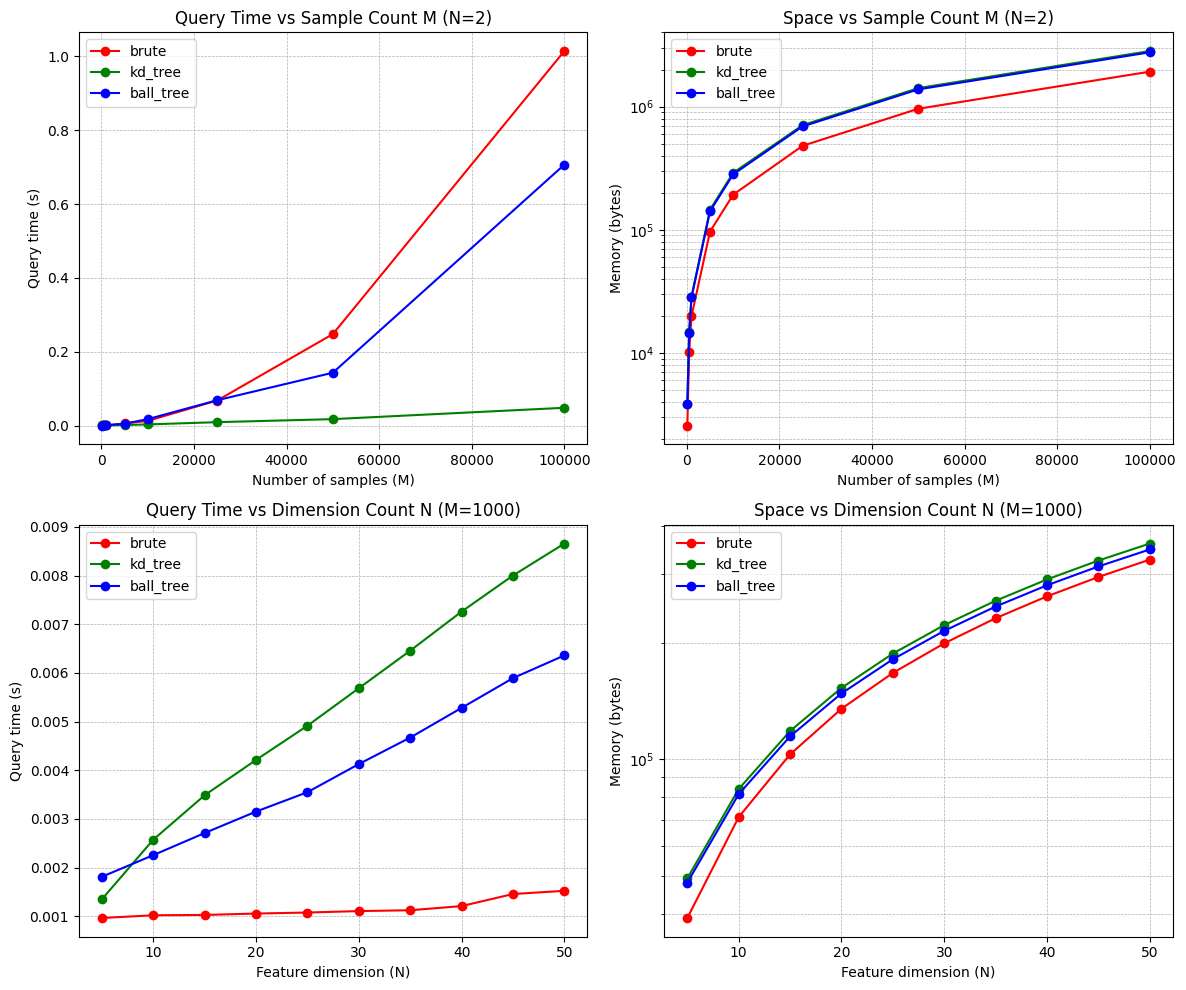

In [12]:
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier

# Number of runs
num_runs = 50

# ---------- Graphs 1 & 2: vary M, fix N=2 ----------
M_values = [100, 500, 1000, 5000, 10000, 25000, 50000, 100000]
N_fixed = 2

time_brute_M, time_kd_M, time_ball_M = [], [], []
space_brute_M, space_kd_M, space_ball_M = [], [], []

for M in M_values:
    X, y = make_classification(
        n_samples=M,
        n_features=N_fixed,
        n_informative=N_fixed,
        n_redundant=0,    # set this to 0
        n_repeated=0,     # set this to 0
        n_classes=2,      # set this to 2
        n_clusters_per_class=1,  # set this to 1
        weights=None,     # set this to NONE
        flip_y=0.02,      # adds noise this determines how difficult the dataset is, optional
        class_sep=0.5,    # separation of classes, larger values make classification easier, optional
        hypercube=True,   # set to True
        shift=0.0, scale=1.0, #set these to (0, 1.0)
        shuffle=True,     # set this to True
        random_state=0,   # set this to 0 or any other integer
    )

    X_train, y_train, X_test, y_test = partition_dataset(X, y, s=0.8, shuffle=True, rng_seed=0)

    # Brute
    model_brute = KNeighborsClassifier(algorithm='brute', n_neighbors=5)
    model_brute.fit(X_train, y_train)
    space_brute_M.append(len(pickle.dumps(model_brute)))
    start = time.time()
    for _ in range(num_runs):
        model_brute.predict(X_test)
    end = time.time()
    time_brute_M.append((end - start)/num_runs)

    # KD-Tree
    model_kd = KNeighborsClassifier(algorithm='kd_tree', n_neighbors=5)
    model_kd.fit(X_train, y_train)
    space_kd_M.append(len(pickle.dumps(model_kd)))
    start = time.time()
    for _ in range(num_runs):
        model_kd.predict(X_test)
    end = time.time()
    time_kd_M.append((end - start)/num_runs)

    # Ball-Tree
    model_ball = KNeighborsClassifier(algorithm='ball_tree', n_neighbors=5)
    model_ball.fit(X_train, y_train)
    space_ball_M.append(len(pickle.dumps(model_ball)))
    start = time.time()
    for _ in range(num_runs):
        model_ball.predict(X_test)
    end = time.time()
    time_ball_M.append((end - start)/num_runs)

# ---------- Graphs 3 & 4: vary N, fix M=1000 ----------
N_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
M_fixed = 1000

time_brute_N, time_kd_N, time_ball_N = [], [], []
space_brute_N, space_kd_N, space_ball_N = [], [], []

for N in N_values:
    X, y = make_classification(
        n_samples=M_fixed,
        n_features=N,
        n_informative=N,
        n_redundant=0,    # set this to 0
        n_repeated=0,     # set this to 0
        n_classes=2,      # set this to 2
        n_clusters_per_class=1,  # set this to 1
        weights=None,     # set this to NONE
        flip_y=0.02,      # adds noise this determines how difficult the dataset is, optional
        class_sep=0.5,    # separation of classes, larger values make classification easier, optional
        hypercube=True,   # set to True
        shift=0.0, scale=1.0, #set these to (0, 1.0)
        shuffle=True,     # set this to True
        random_state=0,   # set this to 0 or any other integer
    )

    X_train, y_train, X_test, y_test = partition_dataset(X, y, s=0.8, shuffle=True, rng_seed=0)

    # Brute
    model_brute = KNeighborsClassifier(algorithm='brute', n_neighbors=5)
    model_brute.fit(X_train, y_train)
    space_brute_N.append(len(pickle.dumps(model_brute)))
    start = time.time()
    for _ in range(num_runs):
        model_brute.predict(X_test)
    end = time.time()
    time_brute_N.append((end - start)/num_runs)

    # KD-Tree
    model_kd = KNeighborsClassifier(algorithm='kd_tree', n_neighbors=5)
    model_kd.fit(X_train, y_train)
    space_kd_N.append(len(pickle.dumps(model_kd)))
    start = time.time()
    for _ in range(num_runs):
        model_kd.predict(X_test)
    end = time.time()
    time_kd_N.append((end - start)/num_runs)

    # Ball-Tree
    model_ball = KNeighborsClassifier(algorithm='ball_tree', n_neighbors=5)
    model_ball.fit(X_train, y_train)
    space_ball_N.append(len(pickle.dumps(model_ball)))
    start = time.time()
    for _ in range(num_runs):
        model_ball.predict(X_test)
    end = time.time()
    time_ball_N.append((end - start)/num_runs)

# ---------- Subplots ----------
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Query Time vs M
axs[0,0].plot(M_values, time_brute_M, 'r-o', label='brute')
axs[0,0].plot(M_values, time_kd_M, 'g-o', label='kd_tree')
axs[0,0].plot(M_values, time_ball_M, 'b-o', label='ball_tree')
axs[0,0].set_xlabel("Number of samples (M)")
axs[0,0].set_ylabel("Query time (s)")
axs[0,0].set_title("Query Time vs Sample Count M (N=2)")
axs[0,0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0,0].legend()

# Plot 2: Space vs M
axs[0,1].plot(M_values, space_brute_M, 'r-o', label='brute')
axs[0,1].plot(M_values, space_kd_M, 'g-o', label='kd_tree')
axs[0,1].plot(M_values, space_ball_M, 'b-o', label='ball_tree')
axs[0,1].set_xlabel("Number of samples (M)")
axs[0,1].set_ylabel("Memory (bytes)")
axs[0,1].set_title("Space vs Sample Count M (N=2)")
axs[0,1].set_yscale("log")
axs[0,1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0,1].legend()

# Plot 3: Query Time vs N
axs[1,0].plot(N_values, time_brute_N, 'r-o', label='brute')
axs[1,0].plot(N_values, time_kd_N, 'g-o', label='kd_tree')
axs[1,0].plot(N_values, time_ball_N, 'b-o', label='ball_tree')
axs[1,0].set_xlabel("Feature dimension (N)")
axs[1,0].set_ylabel("Query time (s)")
axs[1,0].set_title("Query Time vs Dimension Count N (M=1000)")
axs[1,0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1,0].legend()

# Plot 4: Space vs N
axs[1,1].plot(N_values, space_brute_N, 'r-o', label='brute')
axs[1,1].plot(N_values, space_kd_N, 'g-o', label='kd_tree')
axs[1,1].plot(N_values, space_ball_N, 'b-o', label='ball_tree')
axs[1,1].set_xlabel("Feature dimension (N)")
axs[1,1].set_ylabel("Memory (bytes)")
axs[1,1].set_title("Space vs Dimension Count N (M=1000)")
axs[1,1].set_yscale("log")
axs[1,1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1,1].legend()

plt.tight_layout()
plt.show()

## Question II_c: Discussion on results[10 marks]

Discuss whether and why the results were expected or otherwise.

### Your answer here
## Query Time vs Sample count M (N=2)
KD-tree dominates at low dimensions, staying near-flat due to its **O(N log M)** complexity, confirming theoretical expectations. Brute force scales linearly (**O(M·N)**) as expected. Ball-tree grows faster than KD-tree despite sharing the same asymptotic class. This is likely to higher traversal constants from hypersphere partitioning, and is consistent with [1] which concluded that KD-tree consistently outperforms ball-tree across varying dataset sizes, particularly at low dimensionality.

---

## Space vs N and M
As expected, Brute force uses the least memory (no tree overhead), while KD-tree and ball-tree carry additional node/partition metadata at similar cost to each other. Ball-tree is expected to use slightly more space due to it storing hyperspheres (center and radius) for each node, while KD-tree stores less spacious hyperplanes for partitioning, making the observation in the simulation inconcistent with findings from [2]

---

## Query Time vs Dimension count N (M=1000)
Tree-based methods degrade sharply with dimension increase, which is a direct consequence of the **curse of dimensionality**. Brute force remains flat and overtakes both trees consistent with theory. Ball-tree degrades slightly less than KD-tree, which is expected as KD-tree typically only outperforms ball-tree at lower dimensionality. 

---

### Sources:
[1] Munaga, H., & Jarugumalli, V. (2012). *Performance Evaluation: Ball-Tree and KD-Tree 
in the context of MST*. Dept. of Information Technology, University College of 
Engineering, JNTUK.

[2] Paudel, P., & Ghimire, S. (n.d.). *A comparative study of algorithms to determine the K-Nearest Neighbours*. Institute of Engineering, Thapathali Campus, Bagmati, Nepal. Completed as a part of a college practical for Data Mining (CT725). Corresponding author: pratigyapaudel0@gmail.com.